# Conformidade com PROCONVE L8 — Análise Exploratória de Dados
**TCC — Sistemas de Informação | UFU Monte Carmelo**  
**Fonte:** Tabela PBEV 2026 — INMETRO (Janeiro/2026, Rev.04)  
**Pergunta central:** Quais modelos violam os limites de emissão do PROCONVE L8?

In [4]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.1f}'.format)

L8_GAS = {'co_mg_km': 700.0, 'nmog_nox_mg_km': 60.0}
L8_DIE = {'co_mg_km': 500.0, 'nmog_nox_mg_km': 460.0}

COR_OK    = '#2196F3'
COR_VIOLA = '#E53935'
COR_DIE   = '#FF9800'
COR_EV    = '#43A047'
COR_HEV   = '#7B1FA2'
print('Ambiente configurado.')

Ambiente configurado.


## 1. Carregamento e Limpeza

In [5]:
df = pd.read_csv('data/pbev_2026.csv', encoding='utf-8-sig')

df['tipo_propulsao'] = df['tipo_propulsao'].replace({'Hibrido': 'Híbrido', 'Plug-In': 'Plug-in'})
df['marca'] = df['marca'].str.upper().str.strip()
df['grupo_comb'] = df['combustivel'].map({'F':'Flex','G':'Gasolina','D':'Diesel','E':'Elétrico'})

mask_gas = df['combustivel'].isin(['F','G'])
mask_die = df['combustivel'] == 'D'
mask_ev  = df['combustivel'] == 'E'

df['viola_l8'] = False
df.loc[mask_gas, 'viola_l8'] = (
    (df.loc[mask_gas,'co_mg_km'] > L8_GAS['co_mg_km']) |
    (df.loc[mask_gas,'nmog_nox_mg_km'] > L8_GAS['nmog_nox_mg_km'])
)
df.loc[mask_die, 'viola_l8'] = (
    (df.loc[mask_die,'co_mg_km'] > L8_DIE['co_mg_km']) |
    (df.loc[mask_die,'nmog_nox_mg_km'] > L8_DIE['nmog_nox_mg_km'])
)

df_gas = df[mask_gas].copy()
df_die = df[mask_die].copy()

n_gas      = len(df_gas)
n_die      = len(df_die)
n_viol_gas = df_gas['viola_l8'].sum()
n_viol_die = df_die['viola_l8'].sum()

print(f'Total: {len(df)} modelos | {df.marca.nunique()} marcas')
print(f'Gasolina/Flex: {n_gas} | violam L8: {n_viol_gas} ({n_viol_gas/n_gas*100:.1f}%)')
print(f'Diesel:        {n_die} | violam L8: {n_viol_die} ({n_viol_die/n_die*100:.1f}%)')
print(f'Elétrico puro: {mask_ev.sum()}')
df.head(3)

Total: 751 modelos | 39 marcas
Gasolina/Flex: 491 | violam L8: 6 (1.2%)
Diesel:        118 | violam L8: 0 (0.0%)
Elétrico puro: 142


,categoria,marca,modelo,versao,motor,tipo_propulsao,transmissao,combustivel,nmog_nox_mg_km,co_mg_km,nota_verde_l8,co2_fossil_g_km,consumo_mj_km,classificacao_pbe,co_excesso_pct,nmog_excesso_pct,viola_l8,grupo_comb
0,Sub Compacto,BYD,DOLPHIN MINI,GS EV,Elétrico,Elétrico,N.A.,E,0.0,0.0,A,0.0,0.4,A,0.0,0.0,False,Elétrico
1,Sub Compacto,BYD,DOLPHIN MINI,GS 5 EV,Elétrico,Elétrico,N.A.,E,0.0,0.0,A,0.0,0.4,A,0.0,0.0,False,Elétrico
2,Sub Compacto,BYD,DOLPHIN MINI,GL5EV,Elétrico,Elétrico,A-1,E,NaN,NaN,A,NaN,0.4,A,NaN,NaN,False,Elétrico


## 2. Composição da Frota

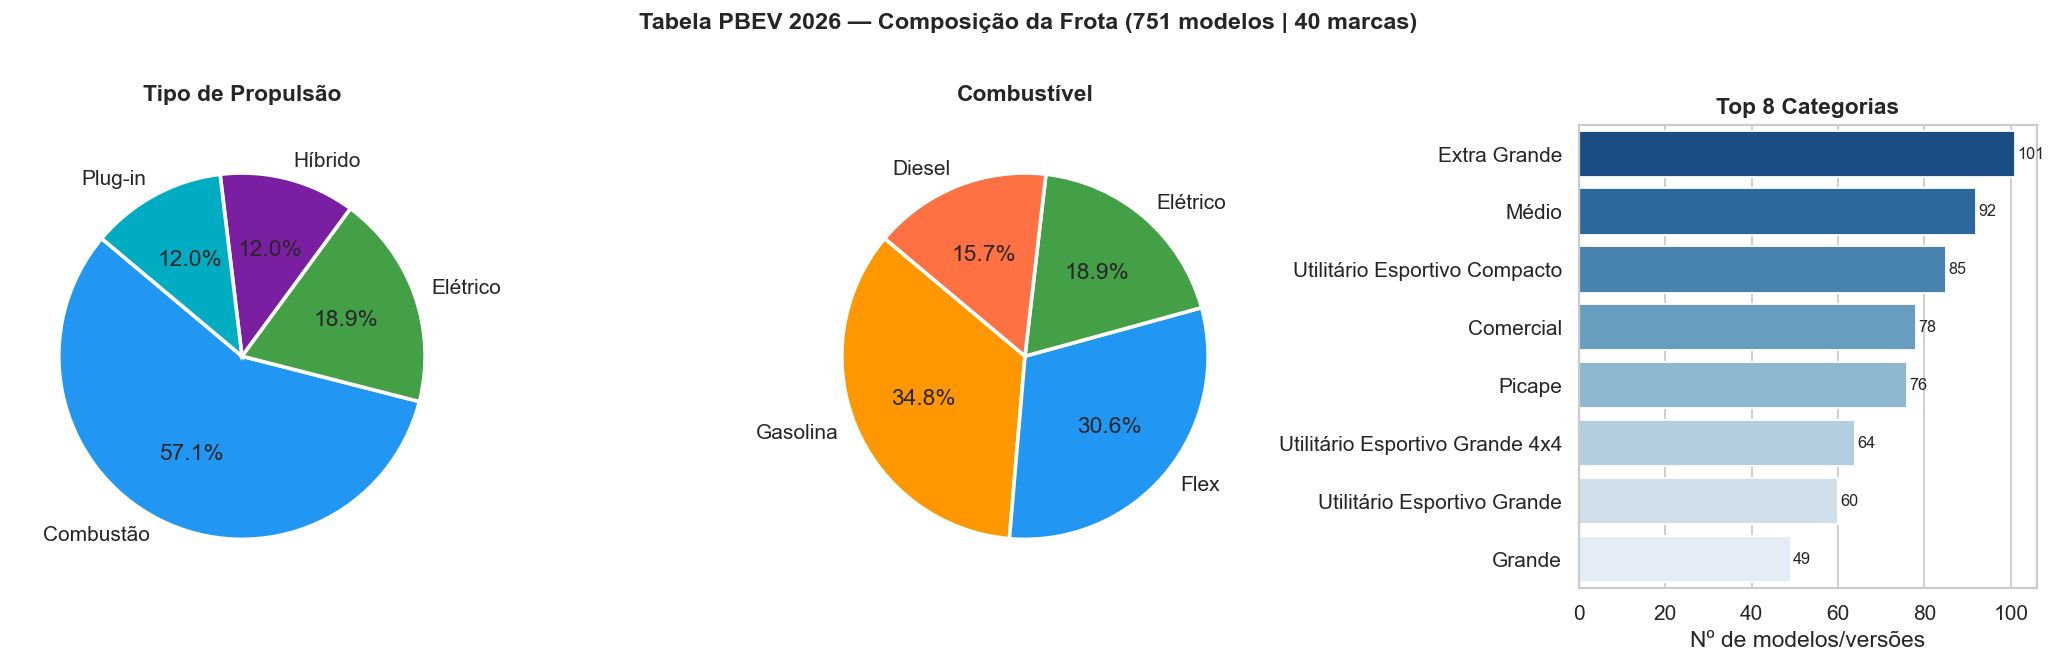

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

prop = df['tipo_propulsao'].value_counts()
axes[0].pie(prop.values, labels=prop.index, autopct='%1.1f%%',
            colors=[COR_OK, COR_EV, COR_HEV, '#00ACC1'],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Tipo de Propulsão', fontweight='bold', pad=15)

comb = df['grupo_comb'].value_counts()
axes[1].pie(comb.values, labels=comb.index, autopct='%1.1f%%',
            colors=[COR_DIE, COR_OK, COR_EV, '#FF7043'],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Combustível', fontweight='bold', pad=15)

cat = df['categoria'].value_counts().head(8)
sns.barplot(y=cat.index, x=cat.values, ax=axes[2], palette='Blues_r')
axes[2].set_xlabel('Nº de modelos/versões')
axes[2].set_ylabel('')
axes[2].set_title('Top 8 Categorias', fontweight='bold')
for i, v in enumerate(cat.values):
    axes[2].text(v+0.5, i, str(v), va='center', fontsize=9)

fig.suptitle('Tabela PBEV 2026 — Composição da Frota (751 modelos | 40 marcas)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_composicao.png', bbox_inches='tight')
plt.show()

## 3. Conformidade L8 — Dispersão CO × NMOG+NOx

=== RESUMO DE CONFORMIDADE ===
Gasolina+Flex: 6/491 violam L8 (1.2%) | Limites: CO≤700, NMOG+NOx≤60 mg/km
Diesel:        0/118 violam L8 (0.0%) | Limites: CO≤500, NMOG+NOx≤460 mg/km


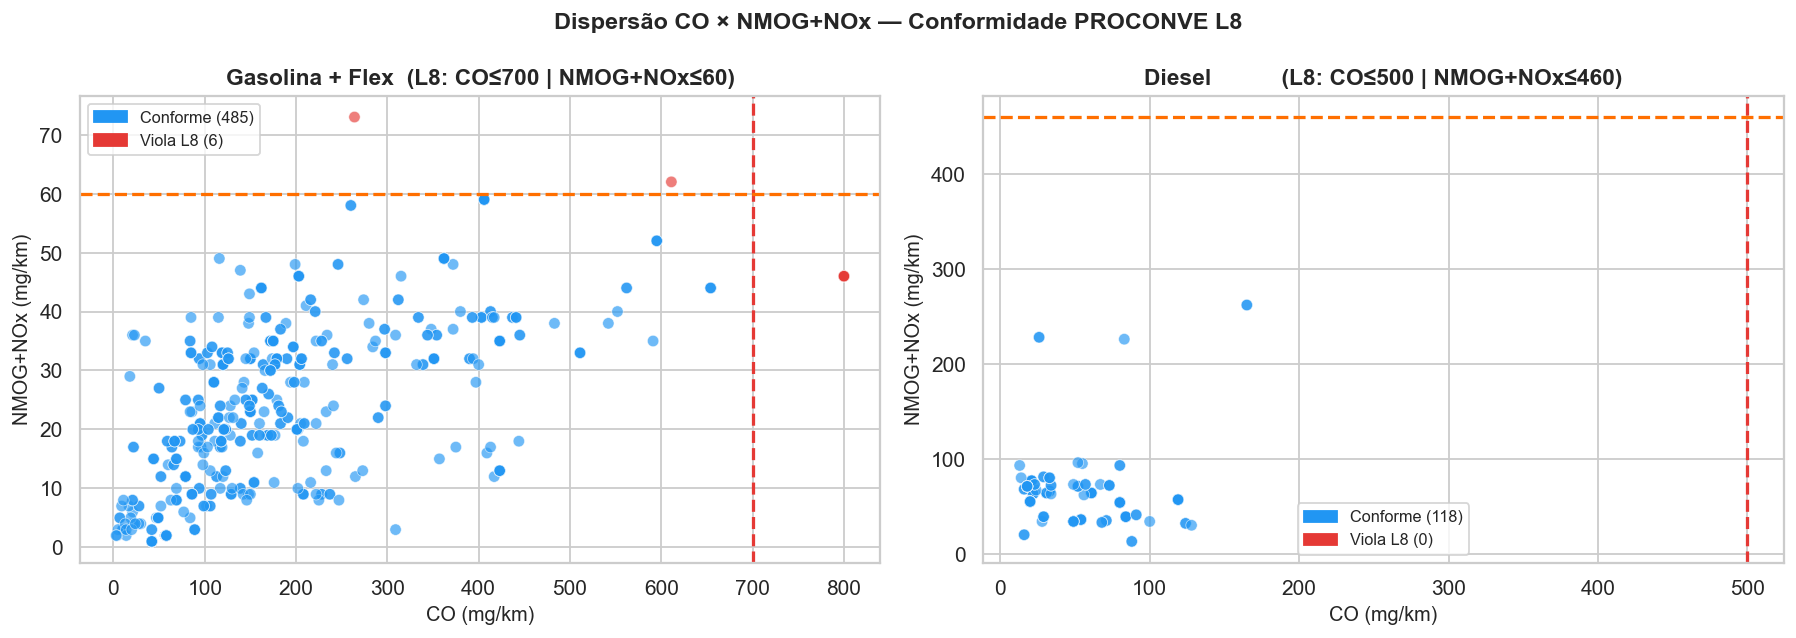

In [7]:
print('=== RESUMO DE CONFORMIDADE ===')
print(f'Gasolina+Flex: {n_viol_gas}/{n_gas} violam L8 ({n_viol_gas/n_gas*100:.1f}%) | Limites: CO≤700, NMOG+NOx≤60 mg/km')
print(f'Diesel:        {n_viol_die}/{n_die} violam L8 ({n_viol_die/n_die*100:.1f}%) | Limites: CO≤500, NMOG+NOx≤460 mg/km')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (subdf, titulo, l8_co, l8_nox) in zip(axes, [
    (df_gas, 'Gasolina + Flex  (L8: CO≤700 | NMOG+NOx≤60)', 700, 60),
    (df_die, 'Diesel           (L8: CO≤500 | NMOG+NOx≤460)', 500, 460),
]):
    cores = [COR_VIOLA if v else COR_OK for v in subdf['viola_l8']]
    ax.scatter(subdf['co_mg_km'], subdf['nmog_nox_mg_km'],
               c=cores, alpha=0.65, s=40, edgecolors='white', linewidths=0.4)
    ax.axvline(l8_co,  color=COR_VIOLA, lw=1.8, ls='--')
    ax.axhline(l8_nox, color='#FF6F00', lw=1.8, ls='--')
    ax.set_xlabel('CO (mg/km)', fontsize=11)
    ax.set_ylabel('NMOG+NOx (mg/km)', fontsize=11)
    ax.set_title(titulo, fontweight='bold')
    n_v = subdf['viola_l8'].sum()
    n_ok = len(subdf) - n_v
    ax.legend(handles=[
        mpatches.Patch(color=COR_OK,    label=f'Conforme ({n_ok})'),
        mpatches.Patch(color=COR_VIOLA, label=f'Viola L8 ({n_v})'),
    ], fontsize=9)

fig.suptitle('Dispersão CO × NMOG+NOx — Conformidade PROCONVE L8', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02_dispersao_l8.png', bbox_inches='tight')
plt.show()

## 4. Distribuição de CO — Gasolina e Flex

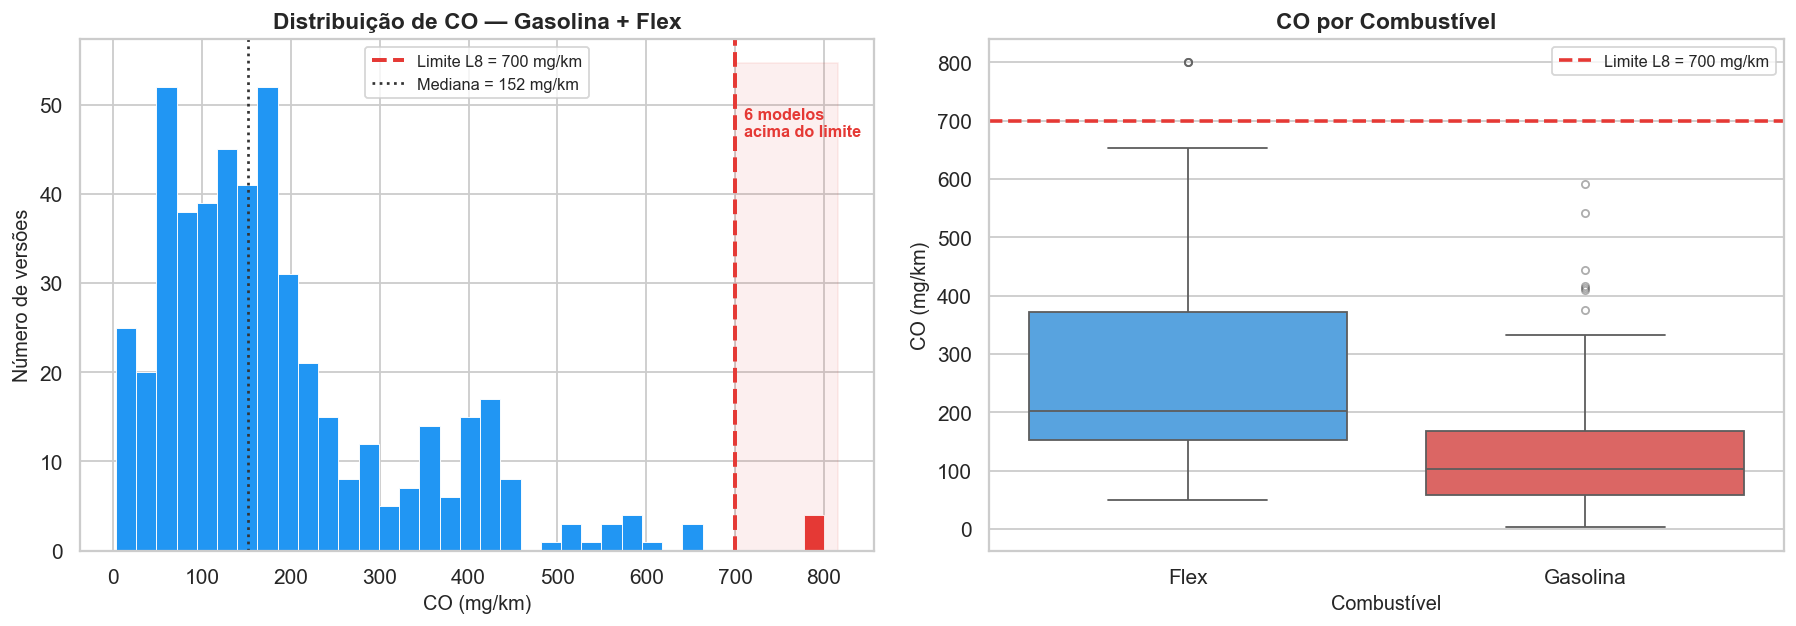

             count  mean   std  min   25%   50%   75%   max
combustivel                                                
F            230.0 264.3 154.2 50.0 153.5 202.0 372.0 800.0
G            261.0 122.2  92.0  3.0  58.0 103.0 169.0 591.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dados_co = df_gas['co_mg_km'].dropna()
counts, edges, patches = axes[0].hist(dados_co, bins=35, edgecolor='white', lw=0.5)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor(COR_VIOLA if left >= 700 else COR_OK)
axes[0].axvline(700, color=COR_VIOLA, lw=2.2, ls='--', label='Limite L8 = 700 mg/km')
axes[0].axvline(dados_co.median(), color='#333', lw=1.5, ls=':', label=f'Mediana = {dados_co.median():.0f} mg/km')
ymax = axes[0].get_ylim()[1]
axes[0].fill_betweenx([0, ymax], 700, dados_co.max()*1.02, alpha=0.08, color=COR_VIOLA)
axes[0].text(710, ymax*0.85, f'{n_viol_gas} modelos\nacima do limite',
             color=COR_VIOLA, fontsize=9, fontweight='bold')
axes[0].set_xlabel('CO (mg/km)', fontsize=11)
axes[0].set_ylabel('Número de versões', fontsize=11)
axes[0].set_title('Distribuição de CO — Gasolina + Flex', fontweight='bold')
axes[0].legend(fontsize=9)

sns.boxplot(data=df_gas.dropna(subset=['co_mg_km']), x='combustivel', y='co_mg_km',
            order=['F','G'], palette={'F':'#42A5F5','G':'#EF5350'}, ax=axes[1],
            flierprops={'marker':'o','markersize':4,'alpha':0.5})
axes[1].axhline(700, color=COR_VIOLA, lw=2, ls='--', label='Limite L8 = 700 mg/km')
axes[1].set_xticklabels(['Flex','Gasolina'])
axes[1].set_xlabel('Combustível', fontsize=11)
axes[1].set_ylabel('CO (mg/km)', fontsize=11)
axes[1].set_title('CO por Combustível', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_03_co_distribuicao.png', bbox_inches='tight')
plt.show()
print(df_gas.groupby('combustivel')['co_mg_km'].describe().round(1))

## 5. Distribuição de NMOG+NOx — Gasolina e Flex

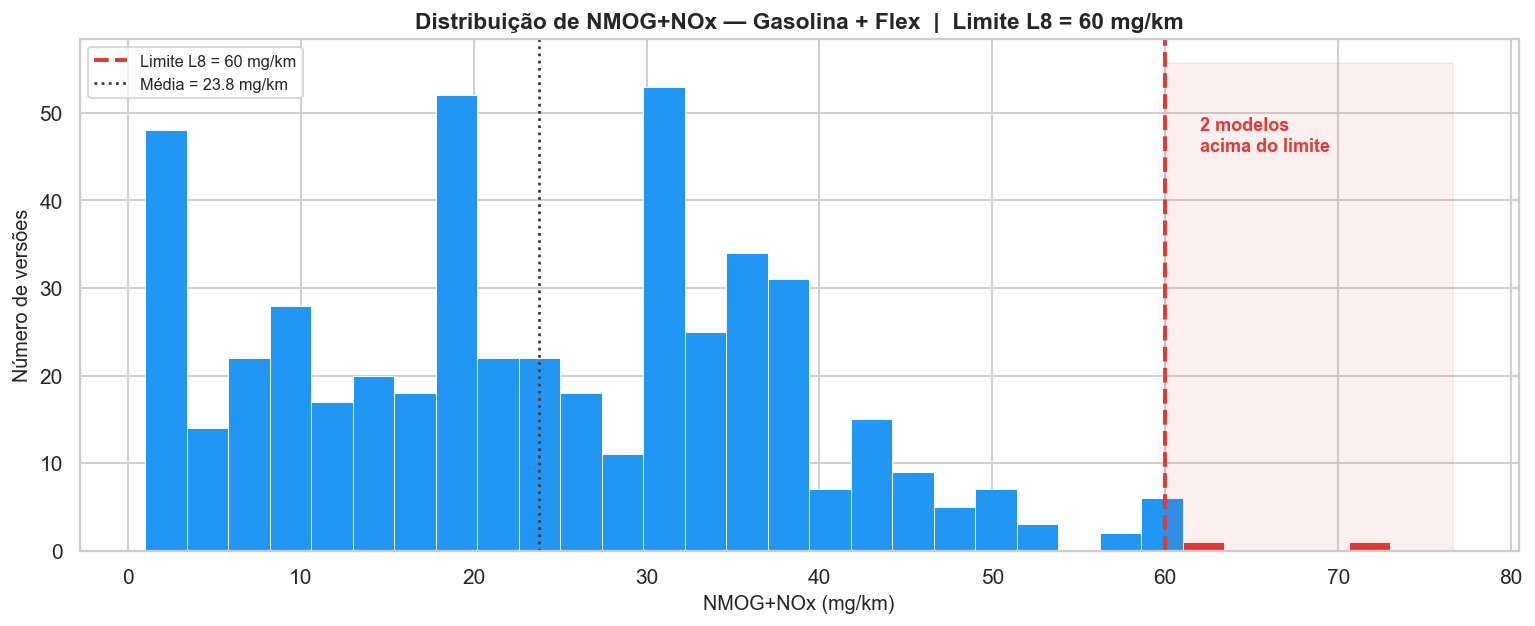

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
dados_nox = df_gas['nmog_nox_mg_km'].dropna()
counts, edges, patches = ax.hist(dados_nox, bins=30, edgecolor='white', lw=0.5)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor(COR_VIOLA if left >= 60 else COR_OK)
ax.axvline(60, color=COR_VIOLA, lw=2.2, ls='--', label='Limite L8 = 60 mg/km')
ax.axvline(dados_nox.mean(), color='#333', lw=1.5, ls=':', label=f'Média = {dados_nox.mean():.1f} mg/km')
n_viol_nox = (dados_nox > 60).sum()
ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax], 60, dados_nox.max()*1.05, alpha=0.08, color=COR_VIOLA)
ax.text(62, ymax*0.82, f'{n_viol_nox} modelos\nacima do limite', color=COR_VIOLA, fontsize=10, fontweight='bold')
ax.set_xlabel('NMOG+NOx (mg/km)', fontsize=11)
ax.set_ylabel('Número de versões', fontsize=11)
ax.set_title('Distribuição de NMOG+NOx — Gasolina + Flex  |  Limite L8 = 60 mg/km', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_04_nmog_distribuicao.png', bbox_inches='tight')
plt.show()

## 6. Top 20 — Maior CO (todos combustíveis)

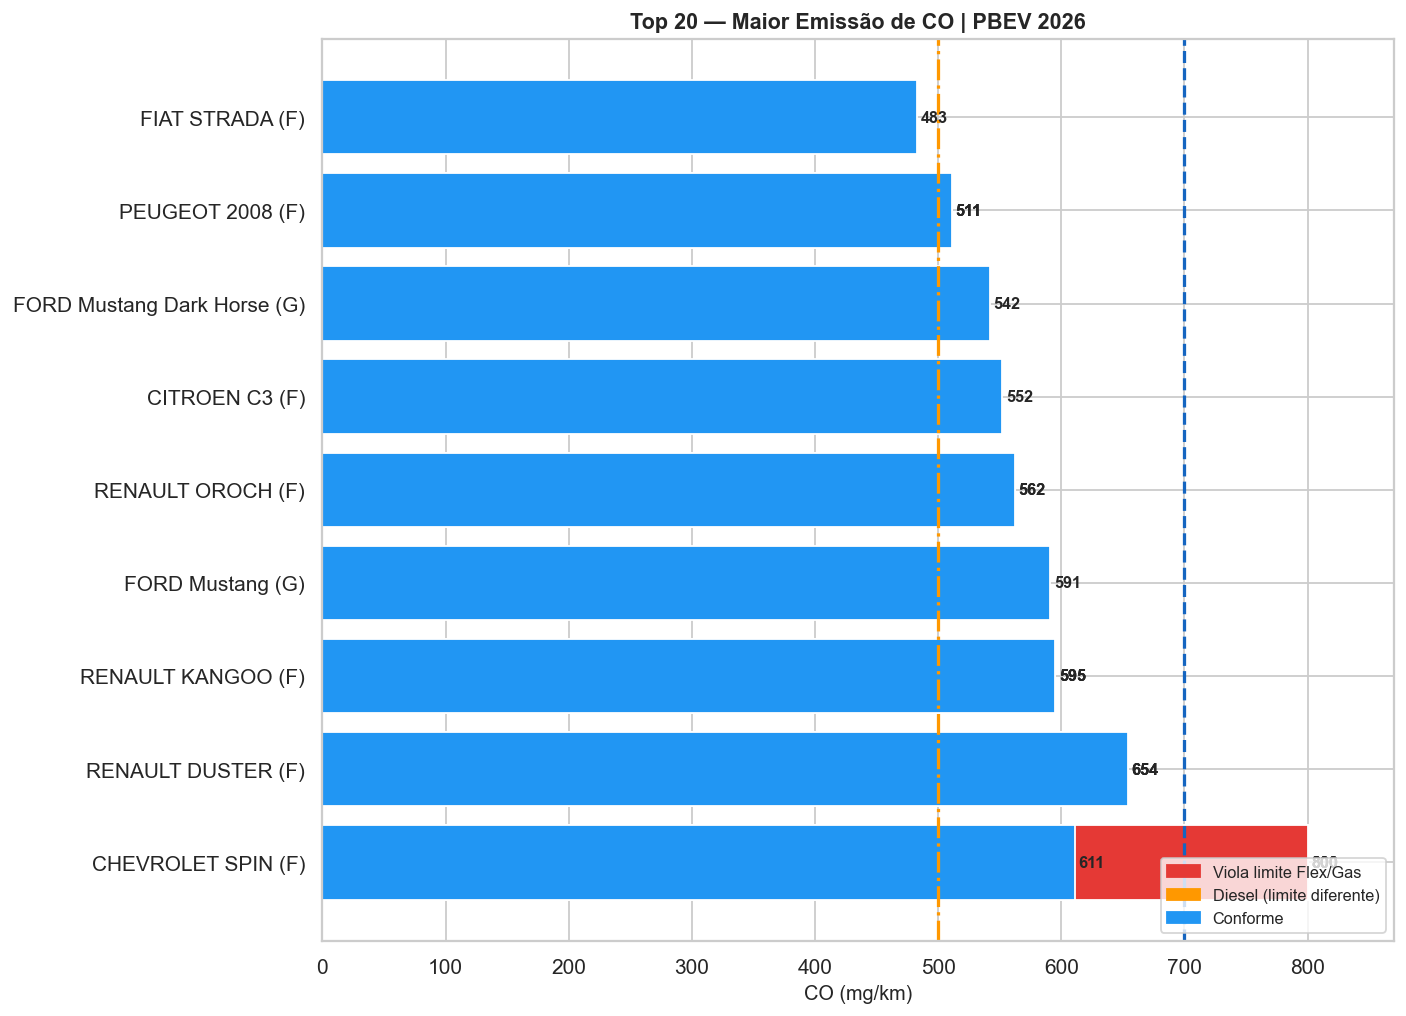

In [10]:
top20 = (
    df[df['co_mg_km'].notna()]
    .assign(rotulo=lambda d: d['marca']+' '+d['modelo']+' ('+d['combustivel']+')')
    .nlargest(20, 'co_mg_km')
)
cores = []
for _, row in top20.iterrows():
    lim = L8_GAS['co_mg_km'] if row['combustivel'] in ('F','G') else L8_DIE['co_mg_km']
    cores.append(COR_VIOLA if row['co_mg_km'] > lim else COR_DIE if row['combustivel']=='D' else COR_OK)

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top20['rotulo'], top20['co_mg_km'], color=cores)
ax.axvline(700, color='#1565C0', lw=1.8, ls='--', label='Limite L8 Flex/Gas = 700 mg/km')
ax.axvline(500, color=COR_DIE,  lw=1.8, ls='-.', label='Limite L8 Diesel = 500 mg/km')
for bar, val in zip(bars, top20['co_mg_km']):
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2, f'{val:.0f}', va='center', fontsize=9, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color=COR_VIOLA, label='Viola limite Flex/Gas'),
    mpatches.Patch(color=COR_DIE,   label='Diesel (limite diferente)'),
    mpatches.Patch(color=COR_OK,    label='Conforme'),
], fontsize=9, loc='lower right')
ax.set_xlabel('CO (mg/km)', fontsize=11)
ax.set_title('Top 20 — Maior Emissão de CO | PBEV 2026', fontweight='bold', fontsize=12)
ax.set_xlim(0, 870)
plt.tight_layout()
plt.savefig('fig_05_top20_co.png', bbox_inches='tight')
plt.show()

## 7. Análise por Marca — Conformidade L8

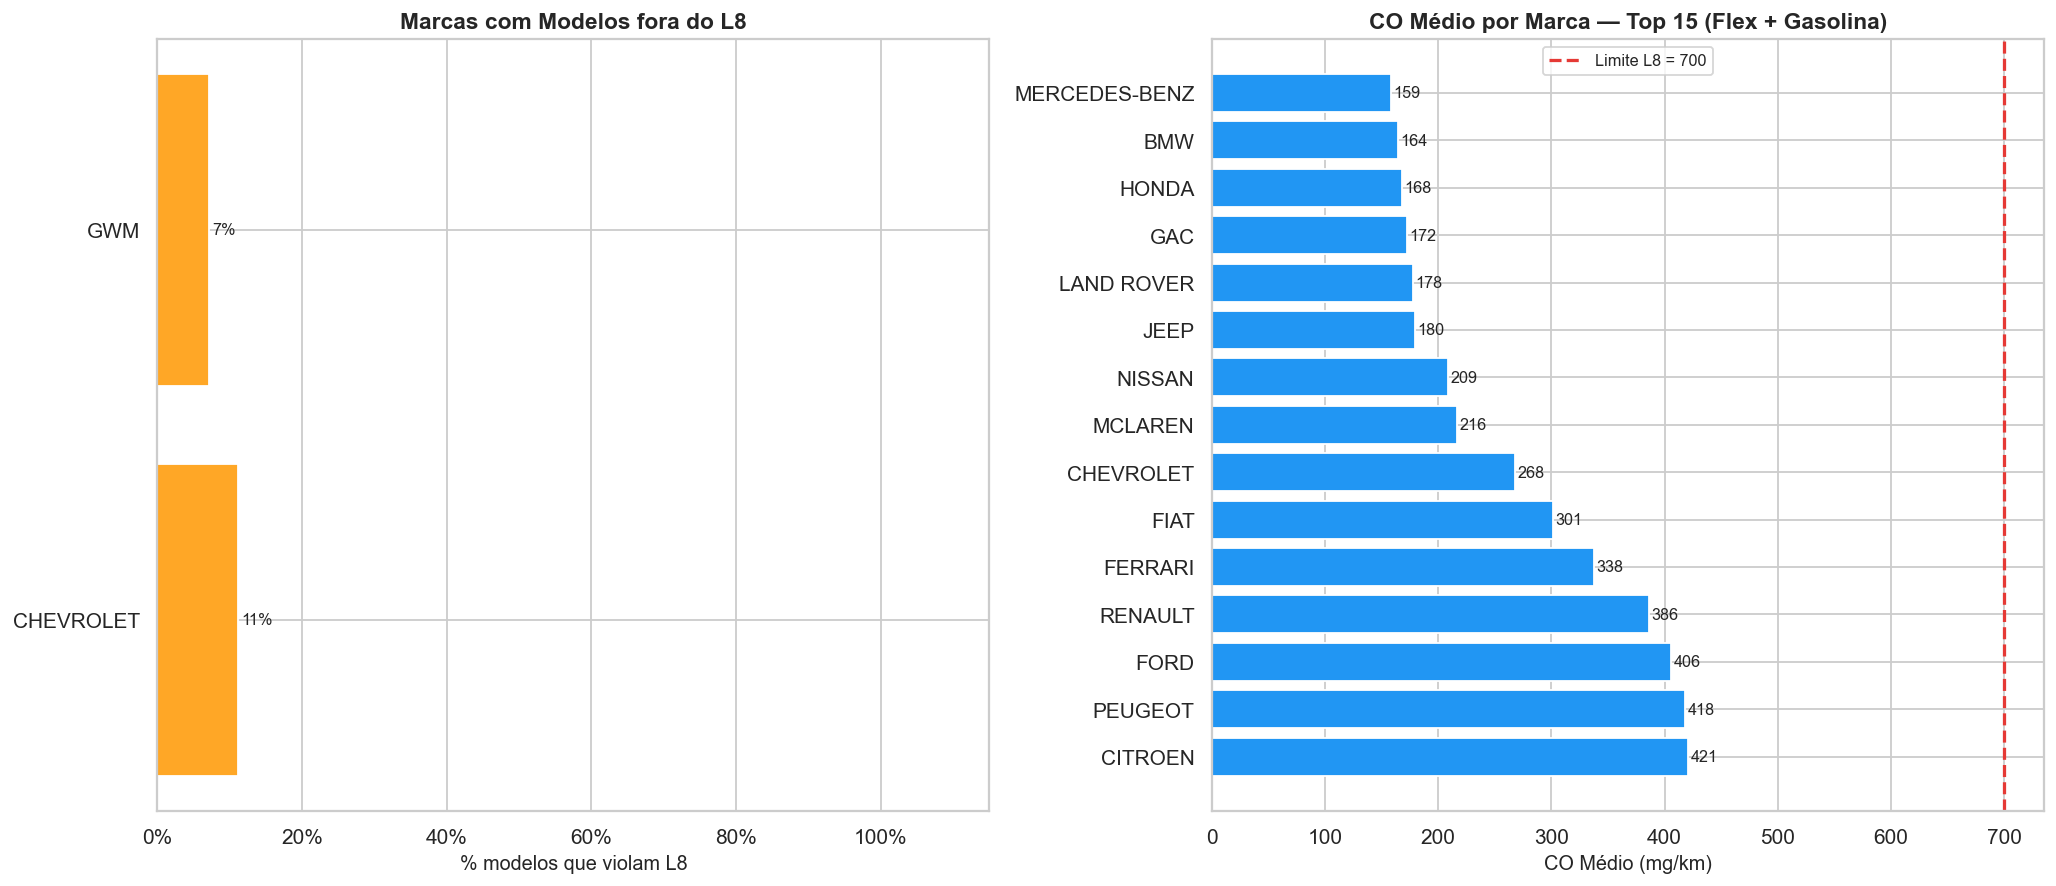

           total  violam  pct_viola
marca                              
CHEVROLET     45       5       11.1
GWM           14       1        7.1


In [11]:
marca_stats = (
    df.groupby('marca')
    .agg(total=('modelo','count'), violam=('viola_l8','sum'),
         co_med=('co_mg_km','mean'))
    .query('total >= 3')
    .assign(pct_viola=lambda d: d['violam']/d['total']*100)
    .sort_values('pct_viola', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

marcas_v = marca_stats[marca_stats['pct_viola'] > 0]
cores_m = [COR_VIOLA if p > 50 else COR_DIE if p > 20 else '#FFA726' for p in marcas_v['pct_viola']]
bars = axes[0].barh(marcas_v.index, marcas_v['pct_viola'], color=cores_m)
for bar, val in zip(bars, marcas_v['pct_viola']):
    axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)
axes[0].set_xlabel('% modelos que violam L8', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_title('Marcas com Modelos fora do L8', fontweight='bold')
axes[0].set_xlim(0, 115)

co_m = (df_gas.groupby('marca')['co_mg_km']
        .agg(['mean','count']).query('count >= 3')
        .sort_values('mean', ascending=False).head(15))
cores_co = [COR_VIOLA if v > 700 else COR_OK for v in co_m['mean']]
bars2 = axes[1].barh(co_m.index, co_m['mean'], color=cores_co)
axes[1].axvline(700, color=COR_VIOLA, lw=1.8, ls='--', label='Limite L8 = 700')
axes[1].set_xlabel('CO Médio (mg/km)', fontsize=11)
axes[1].set_title('CO Médio por Marca — Top 15 (Flex + Gasolina)', fontweight='bold')
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, co_m['mean']):
    axes[1].text(bar.get_width()+2, bar.get_y()+bar.get_height()/2, f'{val:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_06_marca_conformidade.png', bbox_inches='tight')
plt.show()
print(marca_stats[marca_stats['violam']>0][['total','violam','pct_viola']].to_string())

## 8. Análise por Categoria

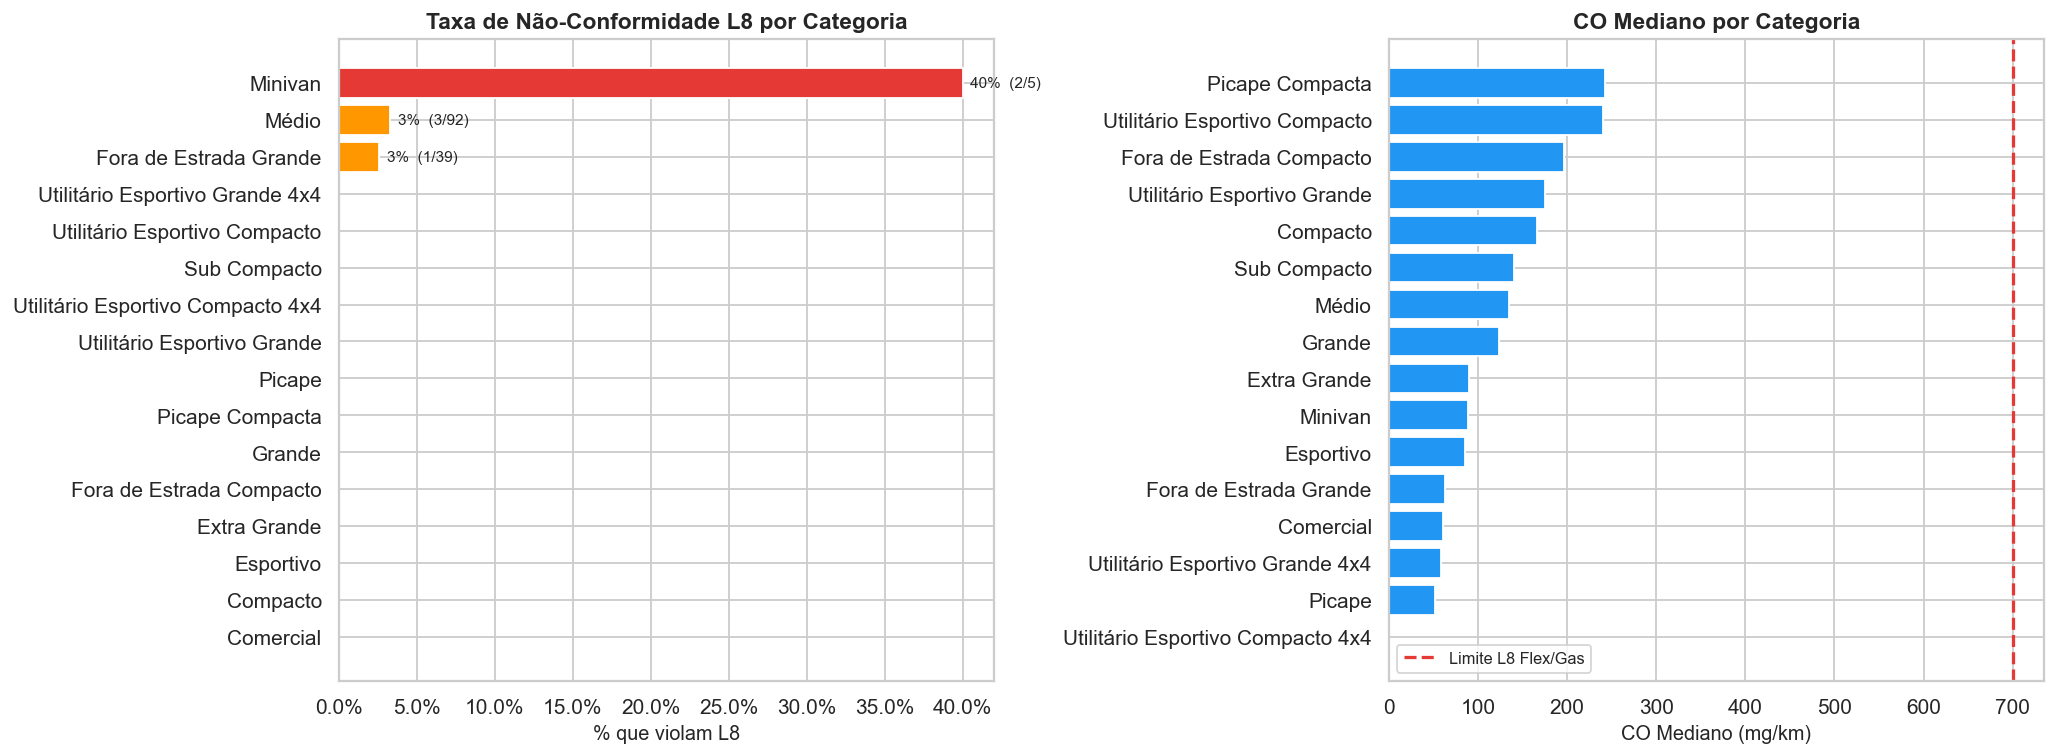

In [12]:
cat_stats = (
    df.groupby('categoria')
    .agg(total=('modelo','count'), violam=('viola_l8','sum'), co_med=('co_mg_km','median'))
    .assign(pct_viola=lambda d: d['violam']/d['total']*100)
    .sort_values('pct_viola', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cores_cat = [COR_VIOLA if p > 30 else COR_DIE if p > 0 else COR_OK for p in cat_stats['pct_viola']]
bars = axes[0].barh(cat_stats.index, cat_stats['pct_viola'], color=cores_cat)
for bar, row in zip(bars, cat_stats.itertuples()):
    if row.violam > 0:
        axes[0].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                     f'{row.pct_viola:.0f}%  ({row.violam}/{row.total})', va='center', fontsize=8.5)
axes[0].set_xlabel('% que violam L8', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].set_title('Taxa de Não-Conformidade L8 por Categoria', fontweight='bold')

cat_ord = cat_stats.sort_values('co_med', ascending=True)
axes[1].barh(cat_ord.index, cat_ord['co_med'],
             color=[COR_VIOLA if v > 700 else COR_DIE if v > 400 else COR_OK for v in cat_ord['co_med']])
axes[1].axvline(700, color=COR_VIOLA, lw=1.8, ls='--', label='Limite L8 Flex/Gas')
axes[1].set_xlabel('CO Mediano (mg/km)', fontsize=11)
axes[1].set_title('CO Mediano por Categoria', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_07_categoria.png', bbox_inches='tight')
plt.show()

## 9. CO₂ Fóssil e Consumo — Combustão × Híbrido × Elétrico

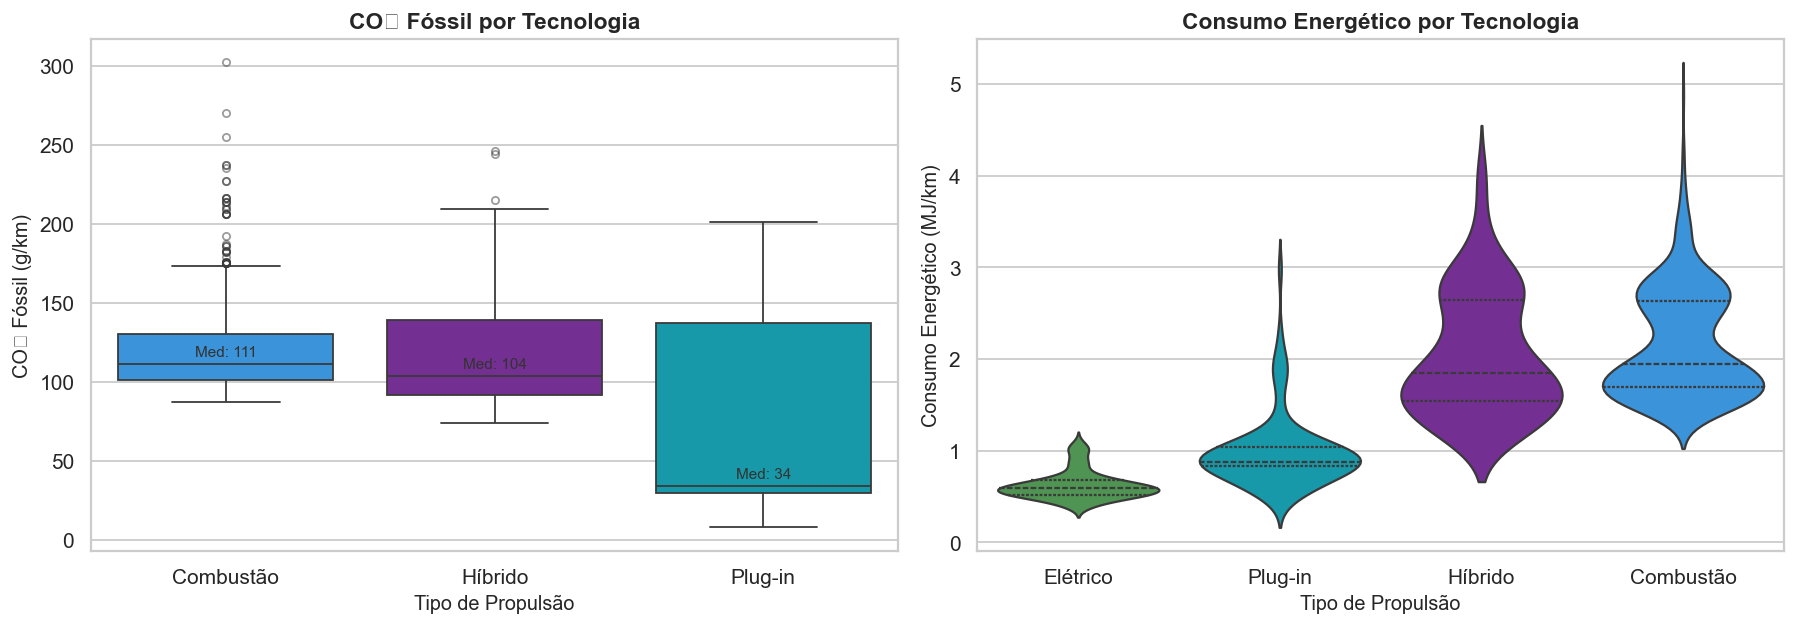

Combustão mediana: 111 g/km | Plug-in mediana: 34 g/km
Redução Plug-in vs Combustão: 69%


In [13]:
df_co2 = df[df['co2_fossil_g_km'].notna() & (df['co2_fossil_g_km'] > 0)]
df_co2 = df_co2[~df_co2['tipo_propulsao'].str.contains('létrico', na=False)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_p = ['Combustão','Híbrido','Plug-in']
pal_p = {'Combustão': COR_OK, 'Híbrido': COR_HEV, 'Plug-in': '#00ACC1'}
sns.boxplot(data=df_co2, x='tipo_propulsao', y='co2_fossil_g_km',
            order=order_p, palette=pal_p, ax=axes[0],
            flierprops={'marker':'o','markersize':4,'alpha':0.5})
axes[0].set_xlabel('Tipo de Propulsão', fontsize=11)
axes[0].set_ylabel('CO₂ Fóssil (g/km)', fontsize=11)
axes[0].set_title('CO₂ Fóssil por Tecnologia', fontweight='bold')
stats = df_co2.groupby('tipo_propulsao')['co2_fossil_g_km'].median()
for i, p in enumerate(order_p):
    if p in stats.index:
        axes[0].text(i, stats[p]+5, f'Med: {stats[p]:.0f}', ha='center', fontsize=8.5, color='#333')

order_all = ['Elétrico','Plug-in','Híbrido','Combustão']
pal_all = {'Elétrico': COR_EV, 'Plug-in': '#00ACC1', 'Híbrido': COR_HEV, 'Combustão': COR_OK}
sns.violinplot(data=df, x='tipo_propulsao', y='consumo_mj_km',
               order=order_all, palette=pal_all, ax=axes[1], inner='quartile')
axes[1].set_xlabel('Tipo de Propulsão', fontsize=11)
axes[1].set_ylabel('Consumo Energético (MJ/km)', fontsize=11)
axes[1].set_title('Consumo Energético por Tecnologia', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_08_co2.png', bbox_inches='tight')
plt.show()

med_comb = df_co2[df_co2['tipo_propulsao']=='Combustão']['co2_fossil_g_km'].median()
med_phev = df_co2[df_co2['tipo_propulsao']=='Plug-in']['co2_fossil_g_km'].median()
print(f'Combustão mediana: {med_comb:.0f} g/km | Plug-in mediana: {med_phev:.0f} g/km')
print(f'Redução Plug-in vs Combustão: {(med_comb-med_phev)/med_comb*100:.0f}%')

## 10. Nota Verde INMETRO × Violação Calculada

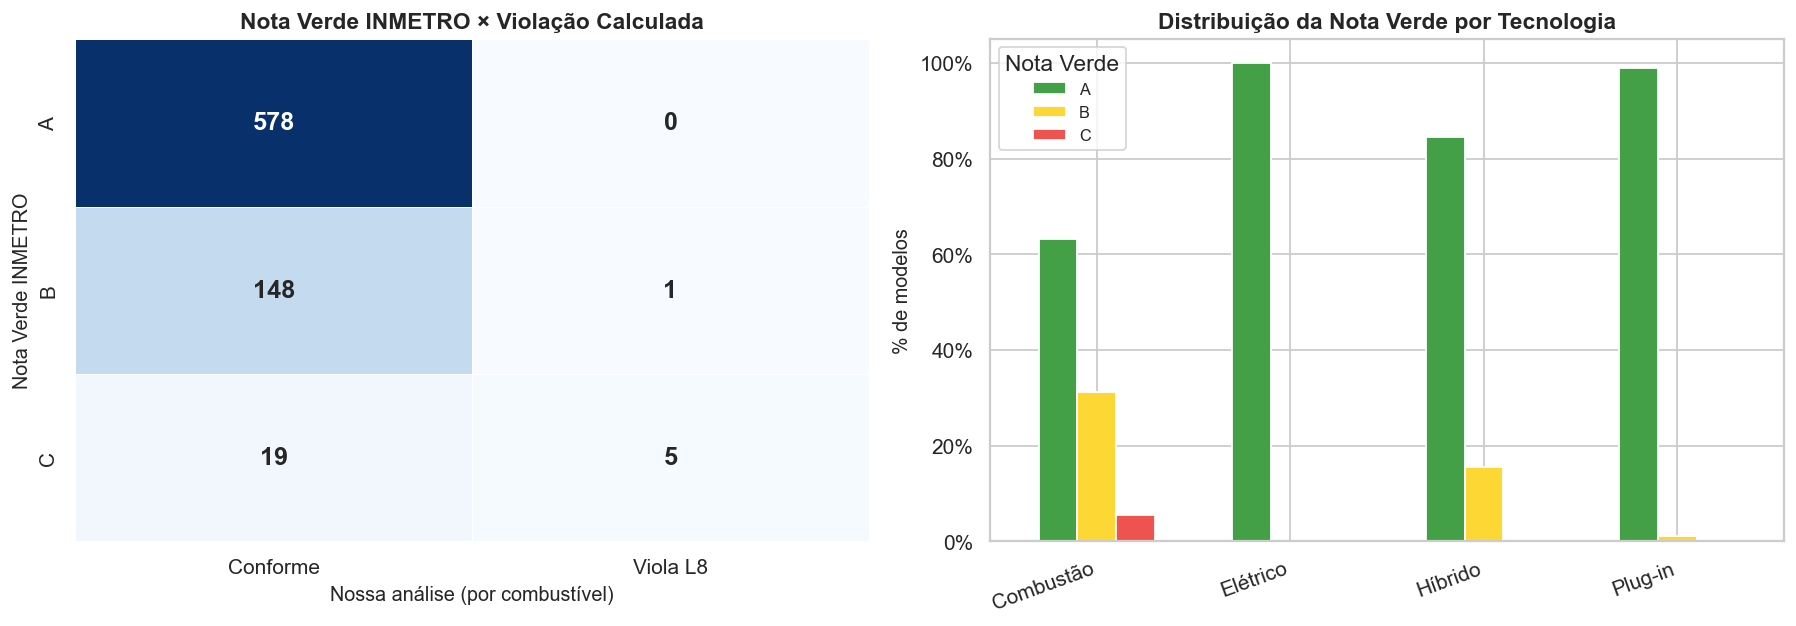

viola_l8       Conforme  Viola L8
nota_verde_l8                    
A                   578         0
B                   148         1
C                    19         5


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cruzamento = pd.crosstab(df['nota_verde_l8'],
    df['viola_l8'].map({True:'Viola L8', False:'Conforme'}))
sns.heatmap(cruzamento, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            ax=axes[0], cbar=False, annot_kws={'size':14,'weight':'bold'})
axes[0].set_title('Nota Verde INMETRO × Violação Calculada', fontweight='bold')
axes[0].set_xlabel('Nossa análise (por combustível)', fontsize=11)
axes[0].set_ylabel('Nota Verde INMETRO', fontsize=11)

prop_nota = pd.crosstab(df['tipo_propulsao'], df['nota_verde_l8'])
prop_nota_pct = prop_nota.div(prop_nota.sum(axis=1), axis=0) * 100
cores_nota = {'A':'#43A047','B':'#FDD835','C':'#EF5350'}
colunas = [c for c in ['A','B','C'] if c in prop_nota_pct.columns]
prop_nota_pct[colunas].plot(kind='bar', ax=axes[1],
    color=[cores_nota[c] for c in colunas], edgecolor='white', width=0.6)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_xlabel('')
axes[1].set_ylabel('% de modelos', fontsize=11)
axes[1].set_title('Distribuição da Nota Verde por Tecnologia', fontweight='bold')
axes[1].legend(title='Nota Verde', fontsize=9)

plt.tight_layout()
plt.savefig('fig_09_nota_verde.png', bbox_inches='tight')
plt.show()
print(cruzamento)

## 11. Classificação PBE × Emissões

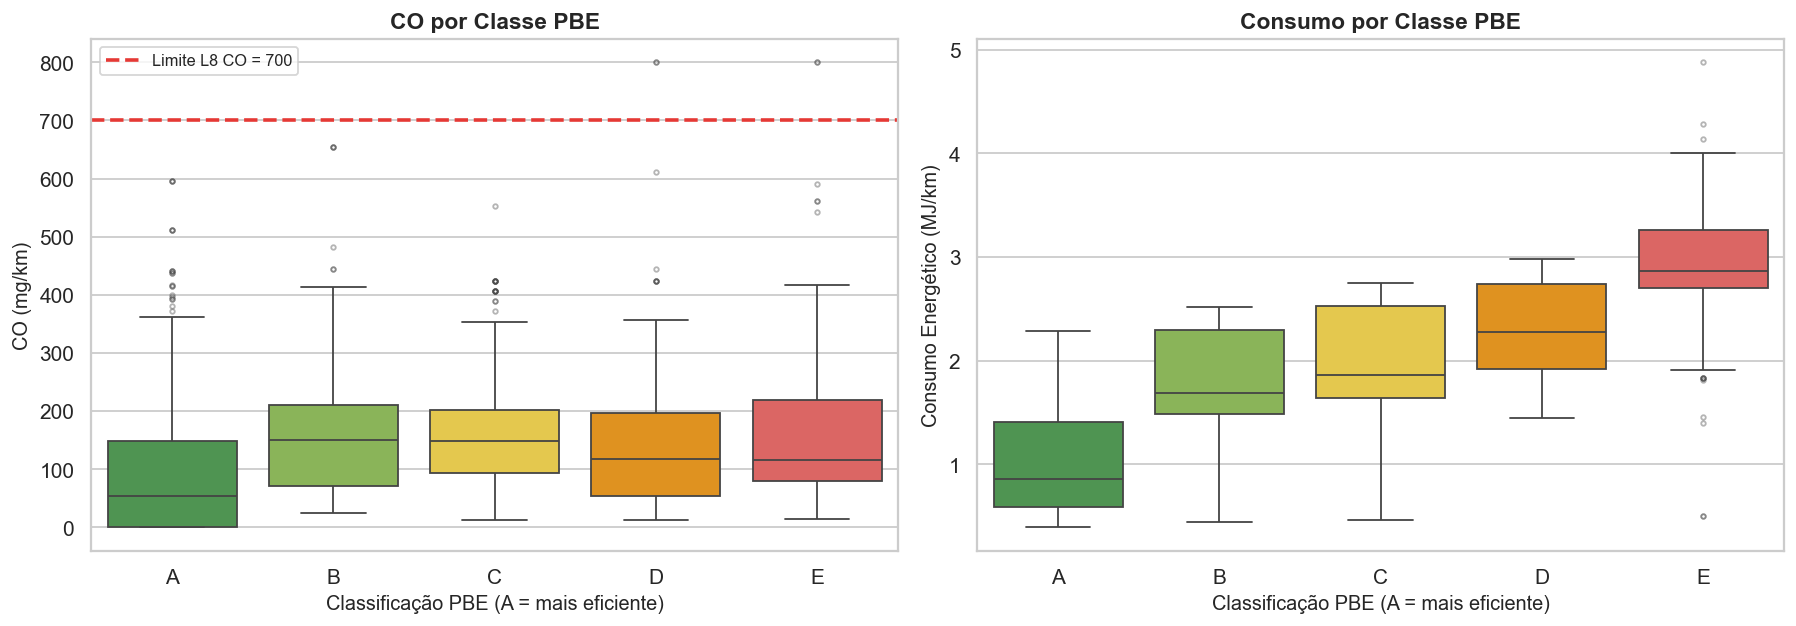

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pal_pbe = {'A':'#43A047','B':'#8BC34A','C':'#FDD835','D':'#FF9800','E':'#EF5350'}
order_pbe = ['A','B','C','D','E']

sns.boxplot(data=df[df['co_mg_km'].notna()], x='classificacao_pbe', y='co_mg_km',
            order=order_pbe, palette=pal_pbe, ax=axes[0],
            flierprops={'marker':'.','markersize':5,'alpha':0.4})
axes[0].axhline(700, color=COR_VIOLA, lw=2, ls='--', label='Limite L8 CO = 700')
axes[0].set_xlabel('Classificação PBE (A = mais eficiente)', fontsize=11)
axes[0].set_ylabel('CO (mg/km)', fontsize=11)
axes[0].set_title('CO por Classe PBE', fontweight='bold')
axes[0].legend(fontsize=9)

sns.boxplot(data=df, x='classificacao_pbe', y='consumo_mj_km',
            order=order_pbe, palette=pal_pbe, ax=axes[1],
            flierprops={'marker':'.','markersize':5,'alpha':0.4})
axes[1].set_xlabel('Classificação PBE (A = mais eficiente)', fontsize=11)
axes[1].set_ylabel('Consumo Energético (MJ/km)', fontsize=11)
axes[1].set_title('Consumo por Classe PBE', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_10_pbe.png', bbox_inches='tight')
plt.show()

## 12. Correlações entre Variáveis Numéricas

In [ ]:
cols = ['co_mg_km','nmog_nox_mg_km','co2_fossil_g_km','consumo_mj_km']
labs = ['CO\n(mg/km)','NMOG+NOx\n(mg/km)','CO₂ Fóssil\n(g/km)','Consumo\n(MJ/km)']
corr = df[cols].corr()
corr.index = labs; corr.columns = labs

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size':13,'weight':'bold'})
ax.set_title('Correlação entre Variáveis de Emissão e Eficiência', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('EDA/fig_11_correlacao.png', bbox_inches='tight')
plt.show()

print('=== TODOS OS PARES — Correlações de Pearson ===')
pares = [
    ('co2_fossil_g_km', 'consumo_mj_km',   'CO₂ Fóssil  × Consumo MJ/km  '),
    ('nmog_nox_mg_km',  'consumo_mj_km',   'NMOG+NOx    × Consumo MJ/km  '),
    ('co_mg_km',        'co2_fossil_g_km',  'CO          × CO₂ Fóssil     '),
    ('nmog_nox_mg_km',  'co2_fossil_g_km',  'NMOG+NOx    × CO₂ Fóssil     '),
    ('co_mg_km',        'consumo_mj_km',    'CO          × Consumo MJ/km  '),
    ('co_mg_km',        'nmog_nox_mg_km',   'CO          × NMOG+NOx       '),
]
interpretacoes = [
    'forte positiva  — causal direta (combustão produz CO₂ proporcional ao combustível)',
    'moderada positiva — maior consumo → mais HC emitidos',
    'moderada positiva — combustão como causa comum',
    'moderada positiva — mesma causa comum da combustão',
    'fraca            — CO independe da quantidade de combustível',
    'quase nula       — controlados independentemente por catalisadores modernos',
]
for (c1, c2, label), interp in zip(pares, interpretacoes):
    r = df[c1].corr(df[c2])
    print(f'  {label}: r = {r:.2f}  →  {interp}')

## 13. Ranking — Modelos Flex/Gasolina que Violam L8

In [18]:
violadores = (
    df_gas[df_gas['viola_l8']]
    .assign(
        exc_co  = lambda d: (d['co_mg_km'] - 700).clip(lower=0),
        exc_nox = lambda d: (d['nmog_nox_mg_km'] - 60).clip(lower=0),
    )
    .sort_values(['exc_co','exc_nox'], ascending=False)
    [['marca','modelo','versao','combustivel',
      'co_mg_km','co_excesso_pct','nmog_nox_mg_km','nmog_excesso_pct',
      'nota_verde_l8','classificacao_pbe']]
    .reset_index(drop=True)
)
violadores.index += 1
print(f'Total de violadores Flex/Gasolina: {len(violadores)}')
display(violadores.style
    .background_gradient(subset=['co_mg_km'], cmap='Reds', vmin=0, vmax=900)
    .background_gradient(subset=['nmog_nox_mg_km'], cmap='Oranges', vmin=0, vmax=80)
    .format({'co_mg_km':'{:.0f}','co_excesso_pct':'{:.1f}%',
             'nmog_nox_mg_km':'{:.0f}','nmog_excesso_pct':'{:.1f}%'})
)

Total de violadores Flex/Gasolina: 6


,marca,modelo,versao,combustivel,co_mg_km,co_excesso_pct,nmog_nox_mg_km,nmog_excesso_pct,nota_verde_l8,classificacao_pbe
1,CHEVROLET,SPIN,AT,F,800,14.3%,46,0.0%,C,E
2,CHEVROLET,SPIN,LT,F,800,14.3%,46,0.0%,C,E
3,CHEVROLET,SPIN,LTZ,F,800,14.3%,46,0.0%,C,D
4,CHEVROLET,SPIN,PREMIER,F,800,14.3%,46,0.0%,C,D
5,GWM,TANK 300,PHEV,G,264,0.0%,73,21.7%,B,A
6,CHEVROLET,SPIN,LT,F,611,0.0%,62,3.3%,C,D


## 14. Síntese dos Principais Achados

In [ ]:
med_comb = df_co2[df_co2['tipo_propulsao']=='Combustão']['co2_fossil_g_km'].median()
med_phev = df_co2[df_co2['tipo_propulsao']=='Plug-in']['co2_fossil_g_km'].median()
r_co_nox = df['co_mg_km'].corr(df['nmog_nox_mg_km'])

fig, ax = plt.subplots(figsize=(13, 9))
ax.axis('off')
achados = [
    ('#1565C0', 'DATASET',     f'{len(df)} modelos/versões · {df.marca.nunique()} marcas · Tabela PBEV 2026 (INMETRO Jan/2026)'),
    ('#1976D2', 'FROTA',       f'57% combustão interna · 19% elétrico puro · 12% híbrido · 12% plug-in'),
    ('#C62828', 'L8 FLEX/GAS', f'{n_viol_gas} de {n_gas} modelos Flex/Gasolina violam PROCONVE L8 ({n_viol_gas/n_gas*100:.1f}%)'),
    ('#B71C1C', 'SPIN 1.8L',   f'5 versões CHEVROLET SPIN 1.8L — CO = 800 mg/km (+14,3%) ou NMOG+NOx = 62 mg/km (+3,3%)'),
    ('#8B0000', 'GWM TANK 300',f'GWM TANK 300 PHEV (Gasolina) — NMOG+NOx = 73 mg/km (+21,7%) · Nota Verde B'),
    ('#E65100', 'DIESEL',       f'Limites L8 diesel diferentes (CO≤500, NMOG+NOx≤460) — {n_viol_die} diesel violam'),
    ('#2E7D32', 'ELÉTRICOS',   f'{mask_ev.sum()} EVs puros: CO₂ fóssil = 0 · Nota Verde A · Consumo ~0.5 MJ/km'),
    ('#4A148C', 'CO₂',         f'Plug-in reduz CO₂ fóssil ~{(med_comb-med_phev)/med_comb*100:.0f}% vs combustão ({med_comb:.0f} → {med_phev:.0f} g/km)'),
    ('#006064', 'CORRELAÇÕES', f'CO × NMOG+NOx: r = {r_co_nox:.2f} (quase nula) — pós-tratamento os controla de forma desacoplada'),
    ('#37474F', 'PBE × L8',    f'Eficiência energética (PBE) é INDEPENDENTE de conformidade L8 — critérios distintos'),
]
for i, (cor, cat, txt) in enumerate(achados):
    y = 0.95 - i * 0.097
    ax.add_patch(plt.Rectangle((0.0, y-0.042), 0.13, 0.075, transform=ax.transAxes,
                                facecolor=cor, clip_on=False))
    ax.text(0.008, y, cat, transform=ax.transAxes, fontsize=8.5,
            color='white', fontweight='bold', va='center')
    ax.text(0.145, y, txt, transform=ax.transAxes, fontsize=9.5, color='#212121', va='center')

ax.set_title('Síntese dos Principais Achados — EDA PBEV 2026',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('EDA/fig_12_sintese.png', bbox_inches='tight')
plt.show()